# 09 Data Gaps and Sovereignty

**Series:** Tribal Soils and Geology

## Data Absence as a Policy Finding

Every notebook in this series surfaced gaps in publicly available geological
and soils data over Pine Ridge and Rosebud. This final notebook synthesizes
those gaps, frames them explicitly as policy findings rather than technical
limitations, and documents the pathway by which Tribal-collected data fills
them.

The key reframing: **the absence of monitoring data on Tribal lands is not
geological uncertainty, it is a federal investment gap with a documented
history.** The Dawes Act and allotment era deliberately fragmented land
management on reservations. The federal trust responsibility for Tribal
lands was consistently underfunded. The result is that the geological and
soils knowledge base for Pine Ridge and Rosebud is systematically thinner
than for surrounding non-Tribal agricultural counties — not because the
geology is less knowable, but because the resources for knowing it were
not provided.

This distinction matters for how we use and present the data in this series.

In [1]:
# Imports
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
import warnings, numpy as np, pandas as pd
import geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, contextily as ctx, yaml
from shapely.geometry import box as sbox
from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED, CRS_WEB, REPO_ROOT as _REPO_ROOT,
    OUTPUTS_DIR, FIGURES_DIR, PINE_RIDGE_BBOX, ROSEBUD_BBOX,
    COMBINED_BBOX, STUDY_BBOX, WSD_3D_MODEL, WSD_KEY_UNITS,
)
from src.loaders import load_tribal_boundaries, load_usgs_well_sites
from src.sovereignty import print_data_acknowledgment, generate_citations
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
with open(_REPO_ROOT / "config" / "config.yaml") as f: CONFIG = yaml.safe_load(f)
TEAL="#007A6E"; TEAL_LT="#E0F4F2"; GRAY="#566573"; TERRACOTTA="#C0392B"
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
primary = load_tribal_boundaries(["Pine Ridge","Rosebud"])
print(f"Ready. Nations: {len(primary)}")

Ready. Nations: 2


In [2]:
# Print data acknowledgement at the top of every notebook
print_data_acknowledgment(source_keys=["usda_ssurgo","usgs_nwis_wells","usgs_3d_model","usgs_state_geology"])

TRIBAL SOILS AND GEOLOGY DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands and subsurface
resources of the Oceti Sakowin, the Lakota, Dakota, and Nakota
peoples. This data is governed by the following frameworks:

OCAP®  : Tribal Nations have the right to Ownership, Control,
         Access, and Possession of data about their lands,
         including subsurface geological and soil data.
         Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous
         peoples, respect their Authority to Control, uphold
         Responsibility to communities, and center Ethics.
         Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, Reusable.
         FAIR governs technical standards; CARE and OCAP® govern
         the ethical obligations FAIR alone does not address.
         Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Pract

## Data Gap Inventory

In [3]:
# Systematic inventory of data gaps identified across the series
data_gaps = [
    {
        "source":    "USDA SSURGO",
        "notebook":  "05, 06",
        "gap":       "Sparse pedon sampling on reservation lands",
        "detail":    ("SSURGO map units on Pine Ridge and Rosebud are frequently "
                      "based on fewer pedons per unit than adjacent non-Tribal counties. "
                      "A single representative pedon may characterize a map unit covering "
                      "thousands of hectares. LEP, AWC, and horizon data are extrapolated "
                      "rather than measured across much of the study area."),
        "policy":    ("USDA NRCS has a trust responsibility to provide soil surveys "
                      "on Tribal lands. The funding and staffing required to bring "
                      "Pine Ridge and Rosebud to the same sampling density as adjacent "
                      "agricultural counties has not been allocated."),
        "tribal_fill": "soil_profile_template.xlsx — field horizon measurements",
    },
    {
        "source":    "USGS NWIS Groundwater",
        "notebook":  "08",
        "gap":       "No USGS monitoring wells documented in reservation bounding boxes",
        "detail":    ("USGS maintains a national groundwater monitoring network. "
                      "The density of monitoring wells on Pine Ridge and Rosebud "
                      "is a fraction of that in surrounding agricultural counties. "
                      "Aquifer characterization for the Ogallala and Madison systems "
                      "on Tribal lands is based on sparse data."),
        "policy":    ("Federal groundwater monitoring investment is driven partly by "
                      "agricultural irrigation demand, which has historically been lower "
                      "on reservation lands due to land use constraints. The result is "
                      "a systematic monitoring gap with direct consequences for water "
                      "security planning."),
        "tribal_fill": "well_log_template.xlsx — lithologic logs and water level measurements",
    },
    {
        "source":    "USGS 3D Model (Spangler 2024)",
        "notebook":  "04, 08",
        "gap":       "Control well density lower on Tribal lands reduces model accuracy",
        "detail":    ("The Spangler (2024) 3D model is the best available subsurface "
                      "framework for the study area, but its accuracy is limited by well "
                      "log density. Areas with fewer control wells have greater uncertainty "
                      "in horizon elevations. Pine Ridge and Rosebud have fewer control "
                      "wells than surrounding areas — so model accuracy is lowest precisely "
                      "where the Tribal land management need is highest."),
        "policy":    ("The model authors document this uncertainty explicitly. Reducing it "
                      "requires drilling and logging wells on Tribal lands — an investment "
                      "that would benefit both the model and local water management."),
        "tribal_fill": "well_log_template.xlsx — each Tribal well log is a new model control point",
    },
    {
        "source":    "USGS State Geologic Map",
        "notebook":  "02, 03",
        "gap":       "State-scale mapping does not resolve reservation-scale variability",
        "detail":    ("The South Dakota state geologic map was compiled at 1:500,000 or "
                      "smaller scale. Formation boundaries on reservation lands reflect "
                      "regional extrapolation from road corridor observations and aerial "
                      "photo interpretation, not systematic field mapping."),
        "policy":    ("Systematic geologic mapping at 1:24,000 scale (7.5-minute quad) "
                      "has not been completed for most of Pine Ridge or Rosebud. This is "
                      "the future quad mapping program — not in scope for this series, "
                      "but the gap is documented here."),
        "tribal_fill": "field_observation_template.xlsx — outcrop and contact observations",
    },
    {
        "source":    "USGS Landslide Hazards",
        "notebook":  "07",
        "gap":       "National landslide inventory incomplete for reservation lands",
        "detail":    ("The USGS national landslide inventory relies on reporting and "
                      "aerial survey coverage that has not been systematically applied "
                      "to Pine Ridge and Rosebud. Landslides on reservation roads and "
                      "valley walls are likely undercounted."),
        "policy":    ("Landslide inventory is a prerequisite for infrastructure siting, "
                      "insurance, and emergency management. The absence of inventory "
                      "data leaves Tribal communities without the hazard characterization "
                      "available to surrounding counties."),
        "tribal_fill": "field_observation_template.xlsx — landslide and slope failure observations",
    },
]

print("DATA GAP INVENTORY for Tribal Soils and Geology Series")
print("=" * 70)
for i, gap in enumerate(data_gaps, 1):
    print(f"\n{i}. {gap['source']} (Notebooks {gap['notebook']})")
    print(f"   Gap: {gap['gap']}")
    print(f"   Detail: {gap['detail'][:120]}...")
    print(f"   Policy: {gap['policy'][:120]}...")
    print(f"   Tribal fill: {gap['tribal_fill']}")

DATA GAP INVENTORY for Tribal Soils and Geology Series

1. USDA SSURGO (Notebooks 05, 06)
   Gap: Sparse pedon sampling on reservation lands
   Detail: SSURGO map units on Pine Ridge and Rosebud are frequently based on fewer pedons per unit than adjacent non-Tribal counti...
   Policy: USDA NRCS has a trust responsibility to provide soil surveys on Tribal lands. The funding and staffing required to bring...
   Tribal fill: soil_profile_template.xlsx — field horizon measurements

2. USGS NWIS Groundwater (Notebooks 08)
   Gap: No USGS monitoring wells documented in reservation bounding boxes
   Detail: USGS maintains a national groundwater monitoring network. The density of monitoring wells on Pine Ridge and Rosebud is a...
   Policy: Federal groundwater monitoring investment is driven partly by agricultural irrigation demand, which has historically bee...
   Tribal fill: well_log_template.xlsx — lithologic logs and water level measurements

3. USGS 3D Model (Spangler 2024) (Notebooks 0

## Gap Severity Assessment

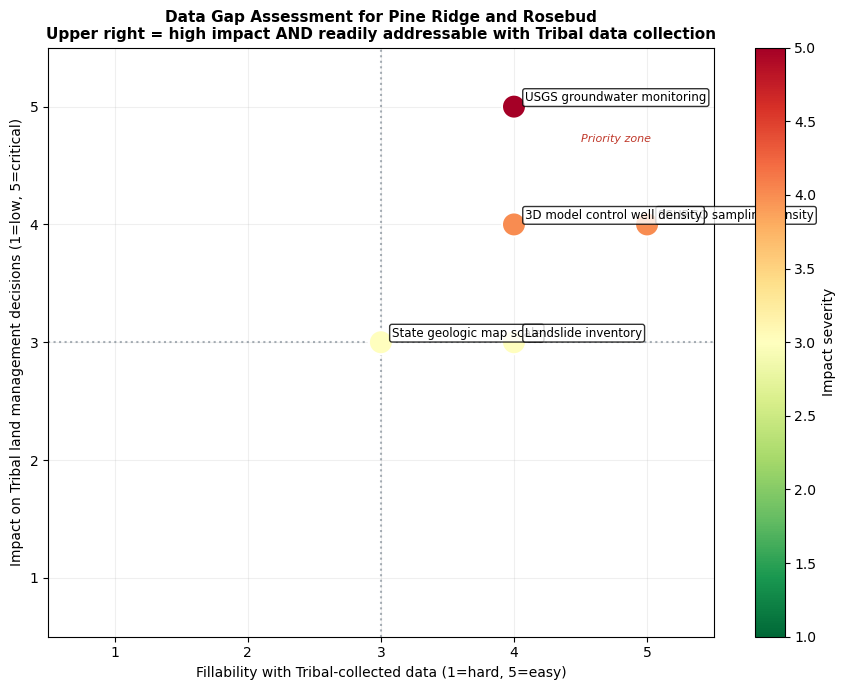

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Score each gap on impact (1-5) and fillability with Tribal data (1-5)
gap_scores = [
    ("SSURGO sampling density",       4, 5),   # impact, fillability
    ("USGS groundwater monitoring",   5, 4),
    ("3D model control well density", 4, 4),
    ("State geologic map scale",      3, 3),
    ("Landslide inventory",           3, 4),
]

names  = [g[0] for g in gap_scores]
impact = [g[1] for g in gap_scores]
fill   = [g[2] for g in gap_scores]

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(fill, impact, s=300, c=impact, cmap="RdYlGn_r",
                vmin=1, vmax=5, zorder=3, edgecolors="white", linewidth=1.5)

for name, f, i in zip(names, fill, impact):
    ax.annotate(name, (f, i), textcoords="offset points",
                xytext=(8, 4), fontsize=8.5,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

ax.set_xlabel("Fillability with Tribal-collected data (1=hard, 5=easy)", fontsize=10)
ax.set_ylabel("Impact on Tribal land management decisions (1=low, 5=critical)", fontsize=10)
ax.set_title("Data Gap Assessment for Pine Ridge and Rosebud\n"
             "Upper right = high impact AND readily addressable with Tribal data collection",
             fontsize=11, fontweight="bold")
ax.set_xlim(0.5, 5.5); ax.set_ylim(0.5, 5.5)
ax.axvline(3, color=GRAY, linestyle=":", alpha=0.5)
ax.axhline(3, color=GRAY, linestyle=":", alpha=0.5)
ax.text(4.5, 4.7, "Priority zone", fontsize=8, color=TERRACOTTA, style="italic")
plt.colorbar(sc, ax=ax, label="Impact severity")
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"09_data_gap_assessment.png", dpi=150, bbox_inches="tight")
plt.show()

## OCAP® Framework for Data Collected on Tribal Lands

Federal agencies collect geological and soils data on Pine Ridge and Rosebud
under their general survey authorities. That data is published as public
domain records. Under current federal practice, Tribal Nations do not have
formal ownership or control over this data.

OCAP®, the First Nations Information Governance Centre's framework for
Ownership, Control, Access, and Possession, provides the analytical
framework for asserting that this situation is incorrect:

**Ownership:** The geological and soils data describes the land itself;
the minerals, the water, the substrate. That land is the sovereign territory
of the Oglala Lakota and Sicangu Lakota peoples. Data about the land is an
extension of the land. The collecting agency is a contractor in service of
understanding, not the owner of what is found.

**Control:** Tribal Nations should have the authority to determine how
geological data about their lands is used; who accesses it, what analyses
are performed, what conclusions are drawn and communicated to whom.

**Access:** Currently, Tribal communities often lack meaningful access to the
federal geological data that describes their lands. SSURGO data requires
GIS software expertise to interpret. Well log data is buried in NWIS.
This series is one step toward making that data accessible.

**Possession:** Tribal Nations should physically hold copies of geological
data about their lands, not be dependent on federal database availability.
The local-file-first design of this repository (data in data/raw/, not
streamed from APIs) is a partial implementation of this principle.

## Pathway Forward

In [5]:
# Synthesize the data collection priorities
print("DATA COLLECTION PRIORITIES for Pine Ridge and Rosebud")
print("Ranked by impact on land and water management decisions")

priorities = [
    (1, "Groundwater well logs",
     "Install and log monitoring wells in key aquifer zones. "
     "Each log is a control point for the 3D model AND a management tool. "
     "Template: well_log_template.xlsx",
     "Critical"),
    (2, "Soil horizon sampling",
     "Stratified sampling of soil profiles across major map units, "
     "prioritizing areas where SSURGO pedon density is lowest. "
     "Template: soil_profile_template.xlsx",
     "High"),
    (3, "Geologic field observations",
     "Systematic outcrop logging along road corridors and stream exposures. "
     "Particular focus on: Pierre Shale contacts, Ogallala extent, "
     "landslide inventory. Template: field_observation_template.xlsx",
     "High"),
    (4, "Slope failure inventory",
     "GPS mapping of active and historic landslide and slump features. "
     "Critical for infrastructure siting decisions and road maintenance. "
     "Use field_observation_template.xlsx with added slope_failure flag.",
     "Moderate"),
    (5, "Water quality sampling",
     "Paired with well logs: water quality at new monitoring wells. "
     "Particular focus on: total dissolved solids, arsenic, nitrate, pH. "
     "Coordinate with tribal_water_monitoring series.",
     "Moderate"),
]

for rank, title, description, urgency in priorities:
    print(f"\n{rank}. {title} [{urgency}]")
    print(f"   {description}")

print()
print("All data collected under this framework is governed by OCAP®.")
print("Templates in data/templates/ are designed for immediate field use.")
print("Data placed in data/raw/ is gitignored and never leaves Tribal control.")

DATA COLLECTION PRIORITIES for Pine Ridge and Rosebud
Ranked by impact on land and water management decisions

1. Groundwater well logs [Critical]
   Install and log monitoring wells in key aquifer zones. Each log is a control point for the 3D model AND a management tool. Template: well_log_template.xlsx

2. Soil horizon sampling [High]
   Stratified sampling of soil profiles across major map units, prioritizing areas where SSURGO pedon density is lowest. Template: soil_profile_template.xlsx

3. Geologic field observations [High]
   Systematic outcrop logging along road corridors and stream exposures. Particular focus on: Pierre Shale contacts, Ogallala extent, landslide inventory. Template: field_observation_template.xlsx

4. Slope failure inventory [Moderate]
   GPS mapping of active and historic landslide and slump features. Critical for infrastructure siting decisions and road maintenance. Use field_observation_template.xlsx with added slope_failure flag.

5. Water quality sampling

## Series Summary

This nine-notebook series has provided:

**Territorial and structural framework** (01): Pine Ridge and Rosebud in
their physiographic and structural context, with the complete stratigraphic
column.

**Surficial and bedrock geology** (02, 03): USGS state geologic map
interpreted for Tribal land management significance, with the Pierre Shale
as the central unit.

**3D subsurface model** (04): The Spangler (2024) USGS 3D model providing
depth-to-formation and cross-section capability for the first time in a
Tribal land context.

**Soils analysis** (05, 06): SSURGO map unit and horizon data with framework
for Tribal-collected soil profiles.

**Hazard characterization** (07): Expansive soils, slope instability, and
radon, framed as infrastructure equity issues rooted in Pierre Shale geology.

**Aquifer geology** (08): The hydrogeologic framework connecting surface
geology to groundwater, with explicit linkage to tribal_water_monitoring.

**Data sovereignty** (09): This notebook, synthesizing gaps as policy
findings and providing the pathway for Tribal data collection under OCAP®.

*Next series: Tribal Agricultural Science: building on the soils foundation
established here for land capability, erosion, and food sovereignty analysis.*

In [6]:
# Print citations
print(generate_citations(["usda_ssurgo","usgs_nwis_wells","usgs_3d_model","usgs_state_geology","census_aiannh"]))

DATA CITATIONS

USDA NRCS SSURGO Soil Survey Geographic Database
  Soil Survey Staff, Natural Resources Conservation Service, United States Department of Agriculture. Web Soil Survey. Available online at https://websoilsurvey.nrcs.usda.gov/.
  https://websoilsurvey.nrcs.usda.gov/
  Steward: USDA Natural Resources Conservation Service (NRCS) | License: Public domain

USGS NWIS Well Logs and Groundwater Data
  U.S. Geological Survey, 2024, National Water Information System data available on the World Wide Web (USGS Water Data for the Nation). https://waterdata.usgs.gov/nwis/
  https://waterdata.usgs.gov/nwis/
  Steward: US Geological Survey | License: Public domain

USGS 3D Geological Model of Western South Dakota
  Spangler, L.R., 2024, Digital data for a 3D Geological Model of western South Dakota, USA: U.S. Geological Survey data release, https://doi.org/10.5066/P9LK4QHJ.
  https://doi.org/10.5066/P9LK4QHJ
  Steward: US Geological Survey, Rocky Mountain Region | License: CC0 1.0 Unive